# V3 GAM — 2021 → 2022 Temporal Calibration & Drift Diagnostic

This notebook is designed specifically for the current Freddie Mac mortgage-credit-risk repository.

### Current temporal design

| Period | Role |
|---|---|
| 2015–2020 | Model training |
| 2021 | Unseen validation / pseudo-OOT |
| 2022 | True OOT |

The notebook **does not retrain the GAM** and **does not fit anything using 2022**.

It loads the persisted model and persisted modelling splits from the repository, generates predictions in Spark in memory, and then checks:

1. 2021 vs 2022 event-rate / PD / AUC / PR-AUC / KS / Brier / LogLoss / O/E
2. risk-decile calibration
3. 2021 vs 2022 calibration curves
4. whether the existing beta calibration transfers to 2022
5. intercept-only and Platt calibration fitted on 2021 and tested on 2022
6. calibration slope/intercept diagnostics
7. 2021 → 2022 feature distribution drift using the model's configured features
8. missingness / population-shift diagnostics
9. a final automatic interpretation

The notebook follows the repository's existing Spark evaluation architecture: persisted model artifacts are loaded, modelling splits are loaded through the configured catalog, and only the small prediction/target columns needed for diagnostics are materialized to Pandas where necessary. The repository's evaluation pipeline likewise loads the validation/OOT parquet splits and applies the fitted Spark model without refitting preprocessing. 


## 1. Locate the repository and load configuration

The notebook searches upward from the current working directory for:

`config/parameters/base.yml`

and adds `src/` to `sys.path`.

This means you can place this notebook under the repository's `notebooks/` directory and run it without hard-coding your local Windows/GCP path.


In [1]:

from __future__ import annotations
import os
import sys
from pathlib import Path

from pyspark.sql import SparkSession, functions as F
from pyspark.sql.window import Window
from pyspark.storagelevel import StorageLevel
from pyspark.ml import PipelineModel
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.functions import vector_to_array
from credit_risk.utils.spark import create_spark_session

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "config" / "parameters" / "base.yml").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate project root. Expected "
        "'config/parameters/base.yml' above the notebook/current directory."
    )

PROJECT_ROOT = find_project_root(Path.cwd())
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))
os.chdir(PROJECT_ROOT)
print("Project root:", PROJECT_ROOT)
print("src path:", SRC_PATH)


Project root: /home/vorad/mortgage-credit-risk
src path: /home/vorad/mortgage-credit-risk/src


In [2]:
from credit_risk.utils.config import read_config
import yaml

config = read_config(Path.cwd())
spark = create_spark_session(config)
modelling_config = config["parameters"]["modelling"]
evaluation_config = config["parameters"].get("evaluation", {})
target_name = config["parameters"]["target"]["name"]
approach = config["parameters"]["modelling_approach"]
engine = config["parameters"]["engine"]

print("Approach:", approach)
print("Engine:", engine)
print("Algorithm:", modelling_config["algorithm"])
print("Model version:", modelling_config["version"])
print("Target:", target_name)
print("Train vintages:", modelling_config["vintages_train"])
print("Validation vintages:", modelling_config["vintages_test"])
print("OOT vintages:", modelling_config["vintages_oot"])


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/vorad/mortgage-credit-risk/.venv/lib/python3.13/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/05 20:42:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Approach: behavioral
Engine: pyspark
Algorithm: gam
Model version: gam_with_interactions_feature_rich
Target: future_90dpd_12m
Train vintages: [2015, 2016, 2017, 2018, 2019, 2020]
Validation vintages: [2021]
OOT vintages: [2022]


## 2. Verify the intended temporal split

The notebook expects the repository configuration to represent:

**2015–2020 → train, 2021 → validation, 2022 → OOT.**

It stops if the configured vintages do not match this design, because silently analyzing the wrong split would invalidate the diagnostic.


In [3]:

expected_train = list(range(2015, 2021))
expected_validation = [2021]
expected_oot = [2022]

actual_train = [int(v) for v in modelling_config["vintages_train"]]
actual_validation = [int(v) for v in modelling_config["vintages_test"]]
actual_oot = [int(v) for v in modelling_config["vintages_oot"]]

assert actual_train == expected_train, (
    f"Expected training vintages {expected_train}, got {actual_train}"
)
assert actual_validation == expected_validation, (
    f"Expected validation vintages {expected_validation}, got {actual_validation}"
)
assert actual_oot == expected_oot, (
    f"Expected OOT vintages {expected_oot}, got {actual_oot}"
)

print("✓ Temporal split verified:")
print("  Train      :", actual_train)
print("  Validation :", actual_validation)
print("  OOT        :", actual_oot)


✓ Temporal split verified:
  Train      : [2015, 2016, 2017, 2018, 2019, 2020]
  Validation : [2021]
  OOT        : [2022]


## 3. Start / reuse Spark

If a `spark` session already exists in the notebook, it is reused. Otherwise a local Spark session is created.

For your current GCP setup, the existing session should normally be reused.


## 4. Load the exact persisted V3 model artifacts

The repository's evaluation code resolves an existing model using the configured model version/type and loads the Spark model artifacts through `load_spark_model_artifacts`.

It also loads the persisted training configuration so that scoring uses the exact feature configuration stored with the trained model rather than accidentally using a changed working configuration.


In [5]:

from copy import deepcopy
from credit_risk.modelling.artifacts_spark import (
    load_spark_model_artifacts,
    load_training_config_spark,
)
from credit_risk.utils.config import create_path

# Mirror the repository's "existing model" resolution.
model_config = deepcopy(config)

if evaluation_config.get("mode") == "existing_model":
    model_config["parameters"]["modelling"]["version"] = (
        evaluation_config["model"]["version"]
    )
    model_config["parameters"]["modelling"]["algorithm"] = (
        evaluation_config["model"]["type"]
    )

training_config = load_training_config_spark(model_config)

# Preserve the exact feature definition used by the trained artifact.
scoring_config = deepcopy(config)
scoring_config["parameters"]["modelling"]["features"] = training_config["features"]

model, preprocessor = load_spark_model_artifacts(config)

print("Loaded model:", type(model).__name__)
print("Loaded preprocessor:", type(preprocessor).__name__)
print(
    "Scoring algorithm:",
    model_config["parameters"]["modelling"]["algorithm"],
)
print(
    "Scoring version:",
    model_config["parameters"]["modelling"]["version"],
)


Loaded model: PipelineModel
Loaded preprocessor: PipelineModel
Scoring algorithm: gam
Scoring version: gam_with_interactions_feature_rich


## 5. Load 2021 validation and 2022 OOT modelling splits

The repository already writes these as `validation_df` and `oot_df`. We load those paths through `create_path`, exactly as the production evaluation pipeline does.

**No predictions are loaded or saved.** Predictions will be generated below directly from the fitted model.


In [6]:

validation_path = create_path(
    config["catalog"]["base"],
    config["catalog"],
    "validation_df",
    approach,
)

oot_path = create_path(
    config["catalog"]["base"],
    config["catalog"],
    "oot_df",
    approach,
)

print("Validation path:", validation_path)
print("OOT path:", oot_path)

validation_df = spark.read.parquet(f"{PROJECT_ROOT}/{str(validation_path)}")
oot_df = spark.read.parquet(f"{PROJECT_ROOT}/{str(oot_path)}")

print("Validation columns:", len(validation_df.columns))
print("OOT columns:", len(oot_df.columns))

validation_count = validation_df.count()
oot_count = oot_df.count()

print(f"2021 validation rows: {validation_count:,}")
print(f"2022 OOT rows:        {oot_count:,}")


Validation path: data/04_model_split/behavioral/validation_split.parquet
OOT path: data/04_model_split/behavioral/oot_split.parquet
Validation columns: 92
OOT columns: 92
2021 validation rows: 15,818,929
2022 OOT rows:        6,138,195


## 6. Generate V3 predictions in Spark

For PySpark evaluation, the repository splits features/target, applies the fitted preprocessing artifact, transforms with the fitted model, and extracts the positive-class probability.

We do the same here, but keep the result in Spark.

Only `label` and `raw_pd` are retained for the core calibration diagnostics, avoiding collection of the large feature matrix.


In [19]:
# ============================================================
# Score Validation (2021) and OOT (2022)
# GAM-specific scoring path
#
# IMPORTANT:
# The persisted GAM PipelineModel owns its own preprocessing:
#   - imputation
#   - categorical indexing
#   - one-hot encoding
#   - spline basis construction
#   - interactions
#   - feature assembly
#   - logistic regression
#
# Therefore:
#
#     raw X -> GAM PipelineModel -> probability
#
# NOT:
#
#     raw X -> outer preprocessor -> GAM PipelineModel
#
# Also:
# Do NOT combine Columns from X and y DataFrames. Spark treats
# them as separate logical DataFrame lineages.
#
# We therefore score X and retrieve the target directly from
# the original dataframe through the scoring DataFrame.
# ============================================================

from pyspark.sql import functions as F
from pyspark.ml.functions import vector_to_array

from credit_risk.modelling.preprocessing_spark import (
    split_features_target_spark,
)


def score_split(df, split_name):
    """
    Score one dataset using the persisted GAM PipelineModel.

    GAM owns its complete preprocessing pipeline, so the outer
    preprocessor is intentionally NOT applied.

    The target remains in the original dataframe and is selected
    from the scored dataframe after model.transform().
    """

    # --------------------------------------------------------
    # 1. Split features and target
    #
    # We only need X for model scoring.
    # --------------------------------------------------------
    X, _ = split_features_target_spark(
        df,
        scoring_config,
    )

    # --------------------------------------------------------
    # 2. Score directly with the persisted GAM PipelineModel
    #
    # IMPORTANT:
    # Do NOT call preprocessor.transform(X) here.
    # --------------------------------------------------------
    predictions = model.transform(X)

    # --------------------------------------------------------
    # 3. Extract probability of class 1
    # --------------------------------------------------------
    predictions = predictions.withColumn(
        "__raw_pd__",
        vector_to_array(
            F.col("probability")
        )[1].cast("double"),
    )

    # --------------------------------------------------------
    # 4. Attach the target safely
    #
    # split_features_target_spark() removed the target from X,
    # so use the original dataframe to obtain it.
    #
    # Since X is derived directly from df without filtering or
    # reordering rows, joining by a generated row identifier is
    # unnecessary. Instead, create the scored dataset directly
    # from the original dataframe below.
    #
    # For robustness, we score a dataframe that retains the
    # target column while the GAM only consumes its configured
    # feature columns.
    # --------------------------------------------------------

    # Re-score with the target retained in the dataframe.
    # Extra columns are ignored by the GAM pipeline.
    scoring_df = df

    predictions_with_target = model.transform(scoring_df)

    predictions_with_target = predictions_with_target.withColumn(
        "__raw_pd__",
        vector_to_array(
            F.col("probability")
        )[1].cast("double"),
    )

    # --------------------------------------------------------
    # 5. Return PD + target + split
    # --------------------------------------------------------
    result = (
        predictions_with_target
        .select(
            F.col("__raw_pd__").alias("raw_pd"),
            F.col(target_name).cast("int").alias("label"),
        )
        .withColumn(
            "split",
            F.lit(split_name),
        )
    )

    return result


# ============================================================
# Score validation and OOT
# ============================================================

print("Scoring validation (2021)...")

val_scored = score_split(
    validation_df,
    "2021",
)

print("Scoring OOT (2022)...")

oot_scored = score_split(
    oot_df,
    "2022",
)


# ============================================================
# Sanity checks
# ============================================================

print("\nValidation rows:", val_scored.count())
print("OOT rows:", oot_scored.count())

print("\nValidation schema:")
val_scored.printSchema()

print("\nOOT schema:")
oot_scored.printSchema()

print("\nValidation sample:")
val_scored.show(5, truncate=False)

print("\nOOT sample:")
oot_scored.show(5, truncate=False)

Scoring validation (2021)...
Scoring OOT (2022)...

Validation rows: 15818929
OOT rows: 6138195

Validation schema:
root
 |-- raw_pd: double (nullable = true)
 |-- label: integer (nullable = true)
 |-- split: string (nullable = false)


OOT schema:
root
 |-- raw_pd: double (nullable = true)
 |-- label: integer (nullable = true)
 |-- split: string (nullable = false)


Validation sample:


26/09/05 16:57:41 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/09/05 16:57:43 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
netlib-blas: JNI_OnLoad: dlopen(libblas.so.3) failed: libblas.so.3: cannot open shared object file: No such file or directory
                                                                                

+---------------------+-----+-----+
|raw_pd               |label|split|
+---------------------+-----+-----+
|0.0011464522648160225|0    |2021 |
|2.871049907682277E-5 |0    |2021 |
|8.156040634309525E-4 |0    |2021 |
|0.0021923793937879132|0    |2021 |
|0.018081512471231465 |0    |2021 |
+---------------------+-----+-----+
only showing top 5 rows

OOT sample:


26/09/05 16:57:44 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB


+---------------------+-----+-----+
|raw_pd               |label|split|
+---------------------+-----+-----+
|0.0017647845730187628|0    |2022 |
|0.0011911273058131666|0    |2022 |
|0.010974060440649525 |0    |2022 |
|0.022962045397365682 |0    |2022 |
|0.00322848026787359  |0    |2022 |
+---------------------+-----+-----+
only showing top 5 rows


## 7. Cache only the compact prediction datasets

These contain only:

- `raw_pd`
- `label`
- `split`

No original feature columns or assembled vectors are cached.


In [20]:

val_scored = val_scored.persist(StorageLevel.MEMORY_AND_DISK)
oot_scored = oot_scored.persist(StorageLevel.MEMORY_AND_DISK)

print("2021 rows:", val_scored.count())
print("2022 rows:", oot_scored.count())


26/09/05 16:57:59 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/09/05 17:00:29 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
                                                                                

2021 rows: 15818929


26/09/05 17:00:30 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
[Stage 557:======================================================>(79 + 1) / 80]

2022 rows: 6138195


26/09/05 17:01:50 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
                                                                                

# Part A — Does the model actually deteriorate in 2022?



In [23]:
# ============================================================
# Core model metrics - Spark native
# ============================================================

from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml.evaluation import BinaryClassificationEvaluator


def core_metrics_spark(scored, split_name):
    """
    Calculate core binary classification + calibration metrics
    entirely in Spark.

    Expected columns:
        raw_pd : predicted probability of class 1
        label  : binary target
    """

    # --------------------------------------------------------
    # 1. Keep only required columns
    # --------------------------------------------------------
    x = (
        scored
        .select(
            F.col("label").cast("double").alias("label"),
            F.col("raw_pd").cast("double").alias("raw_pd"),
        )
        .where(
            F.col("label").isNotNull()
            & F.col("raw_pd").isNotNull()
        )
    )

    # --------------------------------------------------------
    # 2. Basic aggregates
    # --------------------------------------------------------
    agg = (
        x
        .agg(
            F.count("*").alias("n"),
            F.avg("label").alias("event_rate"),
            F.avg("raw_pd").alias("mean_pd"),
            F.avg(
                F.pow(F.col("raw_pd") - F.col("label"), 2)
            ).alias("brier"),
        )
        .first()
    )

    n = int(agg["n"])
    event_rate = float(agg["event_rate"])
    mean_pd = float(agg["mean_pd"])
    brier = float(agg["brier"])

    # --------------------------------------------------------
    # 3. Log loss
    #
    # Clip probabilities away from exactly 0 and 1.
    # --------------------------------------------------------
    eps = 1e-15

    log_loss = (
        x
        .withColumn(
            "p",
            F.when(
                F.col("raw_pd") < eps,
                F.lit(eps),
            )
            .when(
                F.col("raw_pd") > 1 - eps,
                F.lit(1 - eps),
            )
            .otherwise(F.col("raw_pd")),
        )
        .select(
            F.avg(
                -(
                    F.col("label") * F.log(F.col("p"))
                    + (
                        1 - F.col("label")
                    ) * F.log(1 - F.col("p"))
                )
            ).alias("log_loss")
        )
        .first()["log_loss"]
    )

    # --------------------------------------------------------
    # 4. ROC AUC
    # --------------------------------------------------------
    roc_auc = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="raw_pd",
        metricName="areaUnderROC",
    ).evaluate(x)

    # --------------------------------------------------------
    # 5. PR AUC
    # --------------------------------------------------------
    pr_auc = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="raw_pd",
        metricName="areaUnderPR",
    ).evaluate(x)

    # --------------------------------------------------------
    # 6. KS
    #
    # Sort by predicted PD and calculate cumulative event
    # and non-event distributions.
    # --------------------------------------------------------
    events = float(
        x.agg(F.sum("label").alias("events")).first()["events"]
    )

    non_events = float(n - events)

    if events > 0 and non_events > 0:

        w = (
            Window
            .orderBy(F.col("raw_pd"))
            .rowsBetween(
                Window.unboundedPreceding,
                Window.currentRow,
            )
        )

        ks = (
            x
            .withColumn(
                "cum_events",
                F.sum("label").over(w),
            )
            .withColumn(
                "cum_non_events",
                F.sum(
                    1 - F.col("label")
                ).over(w),
            )
            .withColumn(
                "cdf_events",
                F.col("cum_events") / F.lit(events),
            )
            .withColumn(
                "cdf_non_events",
                F.col("cum_non_events") / F.lit(non_events),
            )
            .withColumn(
                "ks_value",
                F.abs(
                    F.col("cdf_events")
                    - F.col("cdf_non_events")
                ),
            )
            .agg(
                F.max("ks_value").alias("ks")
            )
            .first()["ks"]
        )

        ks = float(ks)

    else:
        ks = float("nan")

    # --------------------------------------------------------
    # 7. O/E
    #
    # Observed event rate / mean predicted PD
    # --------------------------------------------------------
    oe = (
        event_rate / mean_pd
        if mean_pd > 0
        else float("nan")
    )

    # --------------------------------------------------------
    # 8. Return Spark Row
    #
    # This is intentionally a Spark Row rather than a Python
    # dictionary so we can union results without pandas.
    # --------------------------------------------------------
    return (
        split_name,
        n,
        event_rate,
        mean_pd,
        oe,
        brier,
        float(log_loss),
        float(roc_auc),
        float(pr_auc),
        ks,
    )


# ============================================================
# Calculate metrics
# ============================================================

val_metrics = core_metrics_spark(
    val_scored,
    "2021",
)

oot_metrics = core_metrics_spark(
    oot_scored,
    "2022",
)


# ============================================================
# Create Spark DataFrame
# ============================================================

metrics_schema = [
    "split",
    "n",
    "event_rate",
    "mean_predicted_pd",
    "O/E",
    "Brier",
    "LogLoss",
    "ROC_AUC",
    "PR_AUC",
    "KS",
]

core_df = spark.createDataFrame(
    [
        val_metrics,
        oot_metrics,
    ],
    schema=metrics_schema,
)


# ============================================================
# Display
# ============================================================



26/09/05 17:03:32 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:03:33 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:03:33 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:03:45 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:03:57 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:03:58 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:03:58 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:03:58 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:03:58 WARN WindowExec: No Partition Defined for Window operatio

DataFrame[split: string, n: bigint, event_rate: double, mean_predicted_pd: double, O/E: double, Brier: double, LogLoss: double, ROC_AUC: double, PR_AUC: double, KS: double]

In [25]:
print(
    core_df.orderBy("split").show()
)

[Stage 635:======================>                             (151 + 28) / 356]

+-----+--------+--------------------+--------------------+------------------+--------------------+--------------------+------------------+-------------------+------------------+
|split|       n|          event_rate|   mean_predicted_pd|               O/E|               Brier|             LogLoss|           ROC_AUC|             PR_AUC|                KS|
+-----+--------+--------------------+--------------------+------------------+--------------------+--------------------+------------------+-------------------+------------------+
| 2021|15818929|0.005447777153560775|0.005640348672578528|0.9658582243409931|0.004733023991741451|0.026161857952632053|0.8421628017140743|0.19090429563762956| 0.510597515669041|
| 2022| 6138195|0.010242424686736085| 0.02607401011210307|0.3928212285988852|0.009787072101908134|0.053047592107426225|0.8122699244157271|0.20671815764981016|0.4465110086518277|
+-----+--------+--------------------+--------------------+------------------+--------------------+------------

### What this table tells us

The key distinction:

- **AUC / KS remain reasonably stable but O/E, Brier and LogLoss deteriorate** → primarily calibration / PD-scale drift.
- **AUC / KS also deteriorate materially** → broader model or population drift.
- A materially different event rate with stable ranking → likely regime/base-rate shift contributing to the PD-scale change.


# Part B — Risk-decile calibration

Deciles are constructed separately within 2021 and 2022, so each period gets its own equal-frequency risk ranking.


In [28]:
# ============================================================
# Risk deciles - Spark native
# ============================================================

from pyspark.sql import functions as F
from pyspark.sql.window import Window


def risk_deciles(scored, split_name, n_bins=10):
    """
    Create risk deciles entirely in Spark.

    Higher risk_decile = higher predicted PD.

    Expected input columns:
        raw_pd : predicted probability of class 1
        label  : binary target
    """

    # --------------------------------------------------------
    # 1. Select required columns
    # --------------------------------------------------------
    x = (
        scored
        .select(
            F.col("label").cast("int").alias("label"),
            F.col("raw_pd").cast("double").alias("raw_pd"),
        )
        .where(
            F.col("label").isNotNull()
            & F.col("raw_pd").isNotNull()
        )
    )

    # --------------------------------------------------------
    # 2. Assign deciles
    #
    # ntile(10) creates approximately equal-sized groups.
    #
    # Sort DESCENDING so:
    #   Decile 1  = highest predicted risk
    #   Decile 10 = lowest predicted risk
    # --------------------------------------------------------
    w = Window.orderBy(F.col("raw_pd").desc())

    x = x.withColumn(
        "risk_decile",
        F.ntile(n_bins).over(w),
    )

    # --------------------------------------------------------
    # 3. Aggregate by risk decile
    # --------------------------------------------------------
    result = (
        x
        .groupBy("risk_decile")
        .agg(
            F.count("*").alias("population"),
            F.sum("label").alias("events"),
            F.avg("label").alias("observed_event_rate"),
            F.avg("raw_pd").alias("average_predicted_pd"),
        )
        .withColumn(
            "split",
            F.lit(split_name),
        )
        .select(
            "split",
            "risk_decile",
            "population",
            "events",
            "observed_event_rate",
            "average_predicted_pd",
        )
        .orderBy("risk_decile")
    )

    return result


# ============================================================
# Generate 2021 and 2022 deciles
# ============================================================

dec_2021 = risk_deciles(
    val_scored,
    "2021",
)

dec_2022 = risk_deciles(
    oot_scored,
    "2022",
)


# ============================================================
# Combine in Spark
# ============================================================

deciles_df = (
    dec_2021
    .unionByName(dec_2022)
    .orderBy(
        "split",
        "risk_decile",
    )
)


# ============================================================
# Display
# ============================================================

display(deciles_df.show())

26/09/05 17:06:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:06:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:06:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:06:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:06:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:06:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 1

+-----+-----------+----------+------+--------------------+--------------------+
|split|risk_decile|population|events| observed_event_rate|average_predicted_pd|
+-----+-----------+----------+------+--------------------+--------------------+
| 2021|          1|   1581893| 48285|0.030523556270872935|   0.029914163424055|
| 2021|          2|   1581893| 12467|0.007881064016339917|0.008353124078447289|
| 2021|          3|   1581893|  8115|0.005129929774011264|0.005514642910366704|
| 2021|          4|   1581893|  5711|0.003610231539048...|0.003933442589269044|
| 2021|          5|   1581893|  3959|0.002502697717228...|0.002885382047010458|
| 2021|          6|   1581893|  2876|0.001818074926685939|0.002126632987759...|
| 2021|          7|   1581893|  2023|0.001278847557957...|0.001548384962628...|
| 2021|          8|   1581893|  1401|8.856477650511128E-4|0.001090644119216...|
| 2021|          9|   1581893|   866|5.474453708310234E-4|7.100071023813857E-4|
| 2021|         10|   1581892|   475| 3.

None

/home/vorad/mortgage-credit-risk/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/05 17:07:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:07:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:07:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:07:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:07:16 WARN DAGScheduler: Broadcas

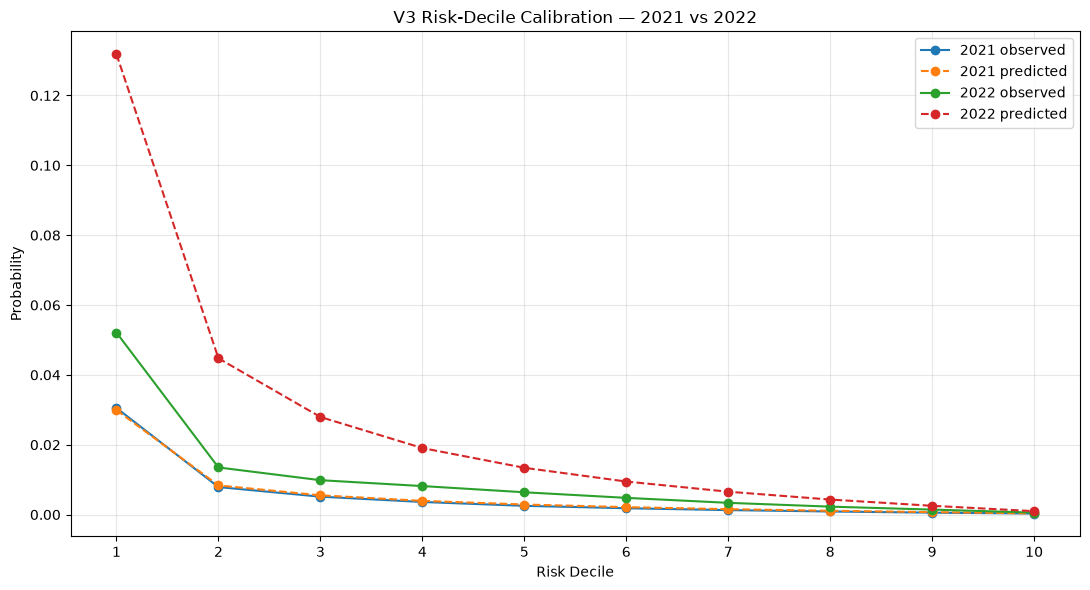

In [31]:
# ============================================================
# Risk-Decile Calibration Plot — 2021 vs 2022
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Collect only the tiny decile summary tables to pandas
# ------------------------------------------------------------
dec_2021_pd = (
    dec_2021
    .orderBy("risk_decile")
    .toPandas()
)

dec_2022_pd = (
    dec_2022
    .orderBy("risk_decile")
    .toPandas()
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6))


for dec, split in [
    (dec_2021_pd, "2021"),
    (dec_2022_pd, "2022"),
]:

    # Observed event rate
    ax.plot(
        dec["risk_decile"],
        dec["observed_event_rate"],
        marker="o",
        label=f"{split} observed",
    )

    # Average predicted PD
    ax.plot(
        dec["risk_decile"],
        dec["average_predicted_pd"],
        marker="o",
        linestyle="--",
        label=f"{split} predicted",
    )


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_xlabel("Risk Decile")
ax.set_ylabel("Probability")
ax.set_title("V3 Risk-Decile Calibration — 2021 vs 2022")

ax.set_xticks(range(1, 11))

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Calibration curve

This is the central visual diagnostic.

If 2021 sits close to the diagonal while 2022 moves systematically below it, the model's **ranking survives but its probability mapping changes in 2022**.


/home/vorad/mortgage-credit-risk/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/05 17:09:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:09:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:09:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:09:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:09:20 WARN DAGScheduler: Broadcas

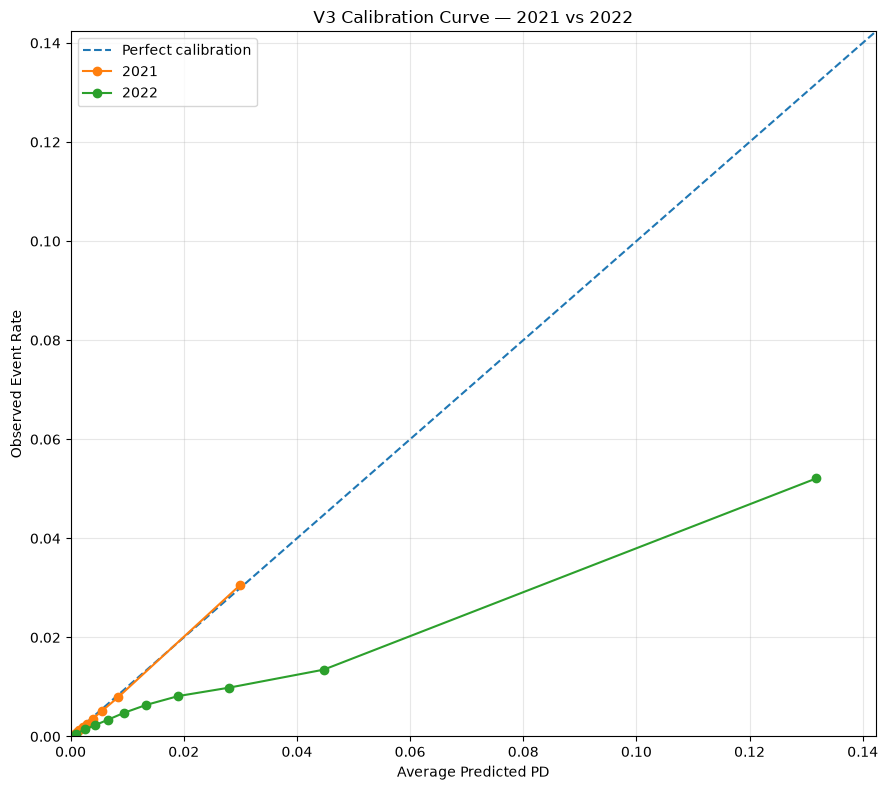

In [33]:
# ============================================================
# V3 Calibration Curve — 2021 vs 2022
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Collect only the 10-row decile summaries to pandas
# ------------------------------------------------------------
dec_2021_pd = (
    dec_2021
    .orderBy("risk_decile")
    .toPandas()
)

dec_2022_pd = (
    dec_2022
    .orderBy("risk_decile")
    .toPandas()
)


# ------------------------------------------------------------
# Determine common axis limit
# ------------------------------------------------------------
max_value = max(
    dec_2021_pd["average_predicted_pd"].max(),
    dec_2021_pd["observed_event_rate"].max(),
    dec_2022_pd["average_predicted_pd"].max(),
    dec_2022_pd["observed_event_rate"].max(),
)

upper = max_value * 1.08


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 8))

# Perfect calibration line
ax.plot(
    [0, upper],
    [0, upper],
    linestyle="--",
    label="Perfect calibration",
)

# 2021
ax.plot(
    dec_2021_pd["average_predicted_pd"],
    dec_2021_pd["observed_event_rate"],
    marker="o",
    label="2021",
)

# 2022
ax.plot(
    dec_2022_pd["average_predicted_pd"],
    dec_2022_pd["observed_event_rate"],
    marker="o",
    label="2022",
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_xlim(0, upper)
ax.set_ylim(0, upper)

ax.set_xlabel("Average Predicted PD")
ax.set_ylabel("Observed Event Rate")
ax.set_title("V3 Calibration Curve — 2021 vs 2022")

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# 2022 Risk-Decile Calibration Gap
# Spark native
# ============================================================

from pyspark.sql import functions as F


# ------------------------------------------------------------
# 1. Calculate decile-level calibration gaps
# ------------------------------------------------------------

decile_gap_2022 = (
    dec_2022
    .select(
        "risk_decile",
        "average_predicted_pd",
        "observed_event_rate",
    )
    .withColumn(
        "pred_minus_observed",
        F.col("average_predicted_pd")
        - F.col("observed_event_rate"),
    )
    .withColumn(
        "pred_over_observed",
        F.when(
            F.col("observed_event_rate") > 0,
            F.col("average_predicted_pd")
            / F.col("observed_event_rate"),
        )
        .otherwise(F.lit(None).cast("double")),
    )
    .orderBy("risk_decile")
)


# ------------------------------------------------------------
# 2. Display decile-level gaps
# ------------------------------------------------------------

display(decile_gap_2022)


# ------------------------------------------------------------
# 3. Extract highest-risk decile
#
# Decile 1 = highest predicted risk because risk_deciles()
# uses descending predicted PD.
# ------------------------------------------------------------

top_decile = (
    decile_gap_2022
    .filter(F.col("risk_decile") == 1)
    .first()
)


# ------------------------------------------------------------
# 4. Print top-decile diagnostics
# ------------------------------------------------------------

if top_decile is not None:

    predicted_pd = top_decile["average_predicted_pd"]
    observed_rate = top_decile["observed_event_rate"]
    pred_over_observed = top_decile["pred_over_observed"]

    print(
        f"2022 top-decile predicted PD: "
        f"{predicted_pd:.4%}"
    )

    print(
        f"2022 top-decile observed rate: "
        f"{observed_rate:.4%}"
    )

    if pred_over_observed is not None:
        print(
            f"2022 top-decile predicted/observed: "
            f"{pred_over_observed:.2f}x"
        )
    else:
        print(
            "2022 top-decile predicted/observed: "
            "undefined (zero observed events)"
        )

DataFrame[risk_decile: int, average_predicted_pd: double, observed_event_rate: double, pred_minus_observed: double, pred_over_observed: double]

26/09/05 17:10:36 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:10:36 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:10:36 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:10:36 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:10:36 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:10:36 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:10:36 WARN WindowExec: No Partition Defined for Window operation! Moving all 

2022 top-decile predicted PD: 13.1797%
2022 top-decile observed rate: 5.2098%
2022 top-decile predicted/observed: 2.53x


# Part C — Calibration model diagnostics

Now we test the important question:

> Is this just a level shift, or are the predictions too extreme?

We fit all candidate calibration models **only on 2021** and evaluate them on both 2021 and 2022.

2022 is never used for fitting.


In [36]:
# ============================================================
# Calibration Features
# ============================================================
#
# We use the Spark prediction frames directly.
# Calibration features are built from the raw model logit.
# ============================================================

from pyspark.sql import functions as F


EPS = 1e-7


def add_logit_features(scored):
    """
    Add clipped probability and logit-based calibration features.

    Expected input columns:
        raw_pd
        label
        split
    """

    return (
        scored

        # ----------------------------------------------------
        # Clip predicted probability to avoid log(0)
        # ----------------------------------------------------
        .withColumn(
            "__p_clip",
            F.when(
                F.col("raw_pd") < EPS,
                F.lit(EPS),
            )
            .when(
                F.col("raw_pd") > 1 - EPS,
                F.lit(1 - EPS),
            )
            .otherwise(
                F.col("raw_pd")
            ),
        )

        # ----------------------------------------------------
        # Raw model logit
        # ----------------------------------------------------
        .withColumn(
            "__logit",
            F.log(
                F.col("__p_clip")
                / (1 - F.col("__p_clip"))
            ),
        )

        # ----------------------------------------------------
        # log(P)
        # ----------------------------------------------------
        .withColumn(
            "__log_p",
            F.log(
                F.col("__p_clip")
            ),
        )

        # ----------------------------------------------------
        # log(1-P)
        # ----------------------------------------------------
        .withColumn(
            "__log_1mp",
            F.log(
                1 - F.col("__p_clip")
            ),
        )
    )


# ============================================================
# Build calibration datasets
# ============================================================

val_cal = add_logit_features(
    val_scored
)

oot_cal = add_logit_features(
    oot_scored
)


# ============================================================
# Sanity check
# ============================================================

print("Validation calibration frame:")
val_cal.select(
    "raw_pd",
    "label",
    "__p_clip",
    "__logit",
    "__log_p",
    "__log_1mp",
).show(5, truncate=False)


print("\nOOT calibration frame:")
oot_cal.select(
    "raw_pd",
    "label",
    "__p_clip",
    "__logit",
    "__log_p",
    "__log_1mp",
).show(5, truncate=False)

Validation calibration frame:


26/09/05 17:11:21 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:11:21 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB


+---------------------+-----+---------------------+-------------------+-------------------+----------------------+
|raw_pd               |label|__p_clip             |__logit            |__log_p            |__log_1mp             |
+---------------------+-----+---------------------+-------------------+-------------------+----------------------+
|0.0011464522648160225|0    |0.0011464522648160225|-6.7699359821617655|-6.771083092105692 |-0.0011471099439269638|
|2.871049907682277E-5 |0    |2.871049907682277E-5 |-10.458218969691753|-10.458247680602984|-2.8710911231090178E-5|
|8.156040634309525E-4 |0    |8.156040634309525E-4 |-7.110765600289981 |-7.111581537139366 |-8.159368493851165E-4 |
|0.0021923793937879132|0    |0.0021923793937879132|-6.120573057589696 |-6.12276784376555  |-0.002194786175854105 |
|0.018081512471231465 |0    |0.018081512471231465 |-3.9946182924719107|-4.012865273134668 |-0.01824698066275754  |
+---------------------+-----+---------------------+-------------------+---------

26/09/05 17:11:22 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB


## 8. Fit intercept-only calibration on 2021

\[
\operatorname{logit}(p_{cal}) =
\operatorname{logit}(p_{raw}) + a
\]

This tests whether the main issue is simply a probability-level/base-rate shift.


In [37]:
# ============================================================
# Intercept-only calibration
# ============================================================
#
# Fit an intercept-only logistic calibration model on 2021.
#
# Calibration form:
#
#     logit(P_calibrated) = a
#
# where `a` is estimated using the 2021 validation sample.
#
# The fitted intercept is then frozen and can be applied to
# 2022 OOT without refitting.
# ============================================================

from pyspark.ml.classification import LogisticRegression
from pyspark.ml.functions import array_to_vector
from pyspark.sql import functions as F


# ------------------------------------------------------------
# 1. Create a constant feature
# ------------------------------------------------------------
#
# A zero-valued feature means its coefficient contributes
# nothing, leaving only the fitted intercept.
# ------------------------------------------------------------

val_intercept = (
    val_cal
    .withColumn(
        "__constant_vector__",
        array_to_vector(
            F.array(F.lit(0.0))
        ),
    )
)


# ------------------------------------------------------------
# 2. Define intercept-only logistic regression
# ------------------------------------------------------------

intercept_lr = LogisticRegression(
    featuresCol="__constant_vector__",
    labelCol="label",
    fitIntercept=True,
    regParam=0.0,
    elasticNetParam=0.0,
    maxIter=50,
)


# ------------------------------------------------------------
# 3. Fit ONLY on 2021
# ------------------------------------------------------------

intercept_model = intercept_lr.fit(
    val_intercept.select(
        "label",
        "__constant_vector__",
    )
)


# ------------------------------------------------------------
# 4. Extract calibration intercept
# ------------------------------------------------------------

intercept_a = float(
    intercept_model.intercept
)


print(
    f"Intercept-only calibration shift a = "
    f"{intercept_a:.6f}"
)

26/09/05 17:11:53 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:11:55 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:11:55 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:11:56 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:11:59 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:11:59 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
                                                                                

Intercept-only calibration shift a = -5.207085


In [40]:
# ============================================================
# Apply true intercept-only calibration
# ============================================================
#
# Intercept-only calibration:
#
#     logit(P_calibrated) = a
#
# Therefore:
#
#     P_calibrated = sigmoid(a)
#
# The raw model PD does NOT enter this transformation.
#
# `a` was fitted on 2021 and is frozen before applying it to
# 2022 OOT.
# ============================================================

from pyspark.sql import functions as F
import math


def apply_intercept_calibration(scored, a):
    """
    Apply a true intercept-only calibration.

    The calibrated probability is the same for every
    observation and equals sigmoid(a).
    """

    calibrated_pd = 1.0 / (
        1.0 + math.exp(-float(a))
    )

    return (
        scored
        .withColumn(
            "__cal_pd__",
            F.lit(calibrated_pd).cast("double"),
        )
    )


# ============================================================
# Apply frozen 2021 calibration
# ============================================================

val_intercept_scored = apply_intercept_calibration(
    val_scored,
    intercept_a,
)

oot_intercept_scored = apply_intercept_calibration(
    oot_scored,
    intercept_a,
)


# ============================================================
# Print calibrated baseline
# ============================================================

calibrated_pd = 1.0 / (
    1.0 + math.exp(-float(intercept_a))
)

print(
    f"Frozen intercept a: {intercept_a:.6f}"
)

print(
    f"Intercept-calibrated PD: {calibrated_pd:.6%}"
)


# ============================================================
# Sanity check
# ============================================================

print("\n2021:")
val_intercept_scored.select(
    "raw_pd",
    "__cal_pd__",
    "label",
).show(5, truncate=False)

print("\n2022:")
oot_intercept_scored.select(
    "raw_pd",
    "__cal_pd__",
    "label",
).show(5, truncate=False)

Frozen intercept a: -5.207085
Intercept-calibrated PD: 0.544778%

2021:


26/09/05 17:13:34 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:13:34 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB


+---------------------+--------------------+-----+
|raw_pd               |__cal_pd__          |label|
+---------------------+--------------------+-----+
|0.0011464522648160225|0.005447777153560777|0    |
|2.871049907682277E-5 |0.005447777153560777|0    |
|8.156040634309525E-4 |0.005447777153560777|0    |
|0.0021923793937879132|0.005447777153560777|0    |
|0.018081512471231465 |0.005447777153560777|0    |
+---------------------+--------------------+-----+
only showing top 5 rows

2022:
+---------------------+--------------------+-----+
|raw_pd               |__cal_pd__          |label|
+---------------------+--------------------+-----+
|0.0017647845730187628|0.005447777153560777|0    |
|0.0011911273058131666|0.005447777153560777|0    |
|0.010974060440649525 |0.005447777153560777|0    |
|0.022962045397365682 |0.005447777153560777|0    |
|0.00322848026787359  |0.005447777153560777|0    |
+---------------------+--------------------+-----+
only showing top 5 rows


26/09/05 17:13:34 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB


## 9. Fit Platt/logistic calibration on 2021

\[
\operatorname{logit}(p_{cal})
=
a+b\operatorname{logit}(p_{raw})
\]

Interpretation:

- \(a\) = probability-level shift
- \(b\) = calibration slope
- \(b pprox 1\) = mostly level shift
- \(b < 1\) = raw model is too extreme / overconfident


In [41]:

from pyspark.ml.linalg import Vectors

val_platt = (
    val_cal
    .withColumn(
        "__platt_features__",
        array_to_vector(F.array(F.col("__logit")))
    )
)

platt_lr = LogisticRegression(
    featuresCol="__platt_features__",
    labelCol="label",
    fitIntercept=True,
    regParam=0.0,
    elasticNetParam=0.0,
    maxIter=100,
)

platt_model = platt_lr.fit(
    val_platt.select("label", "__platt_features__")
)

platt_a = float(platt_model.intercept)
platt_b = float(platt_model.coefficients[0])

print(f"Platt intercept a = {platt_a:.6f}")
print(f"Platt slope     b = {platt_b:.6f}")


26/09/05 17:14:16 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:14:19 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:14:19 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:14:19 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:14:22 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:14:22 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:14:22 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:14:23 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:14:23 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:14:23 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:14:23 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:14:23 WARN DAGScheduler: Broadcasting larg

Platt intercept a = 0.237054
Platt slope     b = 1.064066


In [43]:
# ============================================================
# Apply Platt / Logistic Calibration
# ============================================================
#
# Calibration form:
#
#   logit(P_calibrated)
#       = a + b * logit(P_raw)
#
# `platt_a` and `platt_b` must be fitted ONLY on 2021.
# They are then frozen and applied to both 2021 and 2022.
# ============================================================

from pyspark.sql import functions as F


EPS = 1e-7


def apply_platt(scored, a, b):
    """
    Apply a frozen logistic (Platt-style) calibration model.

    Expected input:
        raw_pd

    Parameters:
        a : calibration intercept
        b : calibration slope
    """

    # --------------------------------------------------------
    # 1. Clip raw PD to avoid log(0) / division by zero
    # --------------------------------------------------------
    p_clip = (
        F.when(
            F.col("raw_pd") < EPS,
            F.lit(EPS),
        )
        .when(
            F.col("raw_pd") > 1 - EPS,
            F.lit(1 - EPS),
        )
        .otherwise(
            F.col("raw_pd")
        )
    )

    # --------------------------------------------------------
    # 2. Convert raw PD to logit
    # --------------------------------------------------------
    raw_logit = F.log(
        p_clip / (1.0 - p_clip)
    )

    # --------------------------------------------------------
    # 3. Apply:
    #
    #     calibrated_logit = a + b * raw_logit
    # --------------------------------------------------------
    calibrated_logit = (
        F.lit(float(a))
        + F.lit(float(b)) * raw_logit
    )

    # --------------------------------------------------------
    # 4. Convert calibrated logit back to probability
    # --------------------------------------------------------
    calibrated_pd = (
        1.0
        / (
            1.0
            + F.exp(-calibrated_logit)
        )
    )

    return scored.withColumn(
        "__cal_pd__",
        calibrated_pd.cast("double"),
    )


# ============================================================
# Apply frozen 2021 calibration parameters
# ============================================================

val_platt_scored = apply_platt(
    val_scored,
    platt_a,
    platt_b,
)

oot_platt_scored = apply_platt(
    oot_scored,
    platt_a,
    platt_b,
)


# ============================================================
# Sanity check
# ============================================================

print(
    f"Platt calibration intercept (a): {platt_a:.6f}"
)

print(
    f"Platt calibration slope (b):     {platt_b:.6f}"
)

print("\n2021:")
val_platt_scored.select(
    "raw_pd",
    "__cal_pd__",
    "label",
).show(5, truncate=False)

print("\n2022:")
oot_platt_scored.select(
    "raw_pd",
    "__cal_pd__",
    "label",
).show(5, truncate=False)

Platt calibration intercept (a): 0.237054
Platt calibration slope (b):     1.064066

2021:


26/09/05 17:15:23 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:15:23 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB


+---------------------+---------------------+-----+
|raw_pd               |__cal_pd__           |label|
+---------------------+---------------------+-----+
|0.0011464522648160225|9.419609833193146E-4 |0    |
|2.871049907682277E-5 |1.8621398845127254E-5|0    |
|8.156040634309525E-4 |6.556225483445473E-4 |0    |
|0.0021923793937879132|0.0018780539747597013|0    |
|0.018081512471231465 |0.017749599429159185 |0    |
+---------------------+---------------------+-----+
only showing top 5 rows

2022:
+---------------------+--------------------+-----+
|raw_pd               |__cal_pd__          |label|
+---------------------+--------------------+-----+
|0.0017647845730187628|0.001490795199371329|0    |
|0.0011911273058131666|9.81075475955819E-4 |0    |
|0.010974060440649525 |0.01043081805114973 |0    |
|0.022962045397365682 |0.022889534315705905|0    |
|0.00322848026787359  |0.002835451204253678|0    |
+---------------------+--------------------+-----+
only showing top 5 rows


26/09/05 17:15:23 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB


## 10. Existing beta calibration — optional

If the repository's current beta-calibrated predictions are already available in the evaluation artifacts, we can compare them later. The important point for this notebook is that **we do not need saved predictions**.

The next cell also fits a standard beta-calibration form on 2021:

\[
\operatorname{logit}(p_{cal})
=
a+b\log(p)+c\log(1-p)
\]

and tests it on 2022.


In [44]:

val_beta = (
    val_cal
    .withColumn(
        "__beta_features__",
        array_to_vector(
            F.array(
                F.col("__log_p"),
                F.col("__log_1mp"),
            )
        )
    )
)

beta_lr = LogisticRegression(
    featuresCol="__beta_features__",
    labelCol="label",
    fitIntercept=True,
    regParam=0.0,
    elasticNetParam=0.0,
    maxIter=100,
)

beta_model = beta_lr.fit(
    val_beta.select("label", "__beta_features__")
)

beta_a = float(beta_model.intercept)
beta_b = float(beta_model.coefficients[0])
beta_c = float(beta_model.coefficients[1])

print(f"Beta intercept a = {beta_a:.6f}")
print(f"Beta coefficient b = {beta_b:.6f}")
print(f"Beta coefficient c = {beta_c:.6f}")


26/09/05 17:15:48 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:15:52 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:15:52 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:15:52 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:15:55 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:15:55 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:15:56 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:15:56 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:15:56 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:15:56 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:15:57 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:15:57 WARN DAGScheduler: Broadcasting larg

Beta intercept a = 0.458193
Beta coefficient b = 1.108721
Beta coefficient c = -0.678478


In [45]:
# ============================================================
# Apply Beta Calibration
# ============================================================
#
# Calibration form:
#
#   z = a + b * log(p) + c * log(1 - p)
#
#   P_calibrated = sigmoid(z)
#
# beta_a, beta_b, beta_c must be fitted ONLY on 2021 and
# frozen before applying to 2022 OOT.
# ============================================================

from pyspark.sql import functions as F


EPS = 1e-7


def apply_beta(scored, a, b, c):
    """
    Apply a frozen beta-calibration transformation.

    Expected input:
        raw_pd

    Parameters:
        a : beta calibration intercept
        b : coefficient on log(p)
        c : coefficient on log(1-p)
    """

    # --------------------------------------------------------
    # 1. Clip raw probability
    # --------------------------------------------------------
    p = (
        F.when(
            F.col("raw_pd") < EPS,
            F.lit(EPS),
        )
        .when(
            F.col("raw_pd") > 1 - EPS,
            F.lit(1 - EPS),
        )
        .otherwise(
            F.col("raw_pd")
        )
    )

    # --------------------------------------------------------
    # 2. Beta calibration logit
    # --------------------------------------------------------
    z = (
        F.lit(float(a))
        + F.lit(float(b)) * F.log(p)
        + F.lit(float(c)) * F.log(1.0 - p)
    )

    # --------------------------------------------------------
    # 3. Convert calibrated logit to probability
    # --------------------------------------------------------
    calibrated_pd = (
        1.0
        / (
            1.0
            + F.exp(-z)
        )
    )

    return scored.withColumn(
        "__cal_pd__",
        calibrated_pd.cast("double"),
    )


# ============================================================
# Apply frozen 2021 beta calibration
# ============================================================

val_beta_scored = apply_beta(
    val_scored,
    beta_a,
    beta_b,
    beta_c,
)

oot_beta_scored = apply_beta(
    oot_scored,
    beta_a,
    beta_b,
    beta_c,
)


# ============================================================
# Sanity check
# ============================================================

print(
    f"Beta calibration intercept (a): {beta_a:.6f}"
)

print(
    f"Beta calibration coefficient (b): {beta_b:.6f}"
)

print(
    f"Beta calibration coefficient (c): {beta_c:.6f}"
)

print("\n2021:")
val_beta_scored.select(
    "raw_pd",
    "__cal_pd__",
    "label",
).show(5, truncate=False)

print("\n2022:")
oot_beta_scored.select(
    "raw_pd",
    "__cal_pd__",
    "label",
).show(5, truncate=False)

Beta calibration intercept (a): 0.458193
Beta calibration coefficient (b): 1.108721
Beta calibration coefficient (c): -0.678478

2021:


26/09/05 17:16:19 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:16:19 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB


+---------------------+---------------------+-----+
|raw_pd               |__cal_pd__           |label|
+---------------------+---------------------+-----+
|0.0011464522648160225|8.681537616528035E-4 |0    |
|2.871049907682277E-5 |1.4562156004785677E-5|0    |
|8.156040634309525E-4 |5.952011561333892E-4 |0    |
|0.0021923793937879132|0.0017810644469447618|0    |
|0.018081512471231465 |0.018368540989765075 |0    |
+---------------------+---------------------+-----+
only showing top 5 rows

2022:
+---------------------+---------------------+-----+
|raw_pd               |__cal_pd__           |label|
+---------------------+---------------------+-----+
|0.0017647845730187628|0.0014003958214802118|0    |
|0.0011911273058131666|9.057340867395875E-4 |0    |
|0.010974060440649525 |0.0105908651309172   |0    |
|0.022962045397365682 |0.02388653643619364  |0    |
|0.00322848026787359  |0.0027348101349671723|0    |
+---------------------+---------------------+-----+
only showing top 5 rows


26/09/05 17:16:19 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB


# Part D — Compare calibration methods on 2021 and 2022

This is the decision table we care about.

A calibration method can look excellent on 2021 and still fail to transfer to 2022. That is why 2022 remains untouched during fitting.


In [47]:
# ============================================================
# Compare Raw vs Calibration Methods
# ============================================================
#
# Methods:
#   Raw
#   Intercept-only
#   Platt
#   Beta
#
# All metric calculations are performed in Spark.
# Only the final 8-row summary is converted to pandas.
# ============================================================

from pyspark.sql import functions as F
from pyspark.ml.evaluation import BinaryClassificationEvaluator


def metrics_for_pd(scored, pd_col, split_name, method):
    """
    Calculate model/calibration metrics for a specified PD
    column.

    Parameters
    ----------
    scored : Spark DataFrame
        Scored dataset.

    pd_col : str
        Column containing predicted PD.

    split_name : str
        Dataset/vintage identifier, e.g. 2021 or 2022.

    method : str
        Calibration method name.
    """

    # --------------------------------------------------------
    # 1. Select PD + target
    # --------------------------------------------------------
    x = (
        scored
        .select(
            F.col("label").cast("double").alias("label"),
            F.col(pd_col).cast("double").alias("pd"),
        )
        .where(
            F.col("label").isNotNull()
            & F.col("pd").isNotNull()
        )
    )

    # --------------------------------------------------------
    # 2. Aggregate metrics
    # --------------------------------------------------------
    agg = (
        x
        .agg(
            F.count("*").alias("n"),
            F.avg("label").alias("event_rate"),
            F.avg("pd").alias("mean_pd"),
            F.avg(
                F.pow(
                    F.col("pd") - F.col("label"),
                    2,
                )
            ).alias("brier"),
        )
        .first()
    )

    n = int(agg["n"])
    event_rate = float(agg["event_rate"])
    mean_pd = float(agg["mean_pd"])
    brier = float(agg["brier"])

    # --------------------------------------------------------
    # 3. Log loss
    # --------------------------------------------------------
    eps = 1e-15

    ll = (
        x
        .withColumn(
            "p",
            F.when(
                F.col("pd") < eps,
                F.lit(eps),
            )
            .when(
                F.col("pd") > 1 - eps,
                F.lit(1 - eps),
            )
            .otherwise(
                F.col("pd")
            ),
        )
        .select(
            F.avg(
                -(
                    F.col("label") * F.log(F.col("p"))
                    +
                    (
                        1 - F.col("label")
                    )
                    * F.log(1 - F.col("p"))
                )
            ).alias("log_loss")
        )
        .first()["log_loss"]
    )

    # --------------------------------------------------------
    # 4. ROC AUC
    # --------------------------------------------------------
    auc = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="pd",
        metricName="areaUnderROC",
    ).evaluate(x)

    # --------------------------------------------------------
    # 5. PR AUC
    # --------------------------------------------------------
    pr_auc = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="pd",
        metricName="areaUnderPR",
    ).evaluate(x)

    # --------------------------------------------------------
    # 6. O/E
    # --------------------------------------------------------
    oe = (
        event_rate / mean_pd
        if mean_pd > 0
        else float("nan")
    )

    # --------------------------------------------------------
    # 7. Return a Python tuple
    #
    # The actual metric calculations remain Spark-native.
    # The tuple is tiny and will be assembled into an
    # 8-row Spark DataFrame below.
    # --------------------------------------------------------
    return (
        split_name,
        method,
        n,
        event_rate,
        mean_pd,
        oe,
        brier,
        float(ll),
        float(auc),
        float(pr_auc),
    )


# ============================================================
# Calculate all comparisons
# ============================================================

comparison_rows = [

    # Raw V3
    metrics_for_pd(
        val_scored,
        "raw_pd",
        "2021",
        "Raw",
    ),

    metrics_for_pd(
        oot_scored,
        "raw_pd",
        "2022",
        "Raw",
    ),

    # Intercept-only calibration
    metrics_for_pd(
        val_intercept_scored,
        "__cal_pd__",
        "2021",
        "Intercept",
    ),

    metrics_for_pd(
        oot_intercept_scored,
        "__cal_pd__",
        "2022",
        "Intercept",
    ),

    # Platt calibration
    metrics_for_pd(
        val_platt_scored,
        "__cal_pd__",
        "2021",
        "Platt",
    ),

    metrics_for_pd(
        oot_platt_scored,
        "__cal_pd__",
        "2022",
        "Platt",
    ),

    # Beta calibration
    metrics_for_pd(
        val_beta_scored,
        "__cal_pd__",
        "2021",
        "Beta",
    ),

    metrics_for_pd(
        oot_beta_scored,
        "__cal_pd__",
        "2022",
        "Beta",
    ),
]


# ============================================================
# Create Spark comparison table
# ============================================================

comparison_schema = [
    "split",
    "method",
    "n",
    "event_rate",
    "mean_pd",
    "O/E",
    "Brier",
    "LogLoss",
    "ROC_AUC",
    "PR_AUC",
]


comparison_metrics_spark = spark.createDataFrame(
    comparison_rows,
    schema=comparison_schema,
)


# ============================================================
# Display
# ============================================================



26/09/05 17:16:56 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:16:57 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:16:58 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:17:09 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:17:21 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:17:21 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:17:22 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:17:29 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:17:36 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:17:36 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:17:37 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:17:38 WARN DAGScheduler: Broadcasting larg

DataFrame[split: string, method: string, n: bigint, event_rate: double, mean_pd: double, O/E: double, Brier: double, LogLoss: double, ROC_AUC: double, PR_AUC: double]

In [48]:
display(
    comparison_metrics_spark
    .orderBy(
        "split",
        F.when(F.col("method") == "Raw", 1)
         .when(F.col("method") == "Intercept", 2)
         .when(F.col("method") == "Platt", 3)
         .when(F.col("method") == "Beta", 4)
         .otherwise(99),
    ).show()
)

+-----+---------+--------+--------------------+--------------------+-------------------+--------------------+--------------------+------------------+--------------------+
|split|   method|       n|          event_rate|             mean_pd|                O/E|               Brier|             LogLoss|           ROC_AUC|              PR_AUC|
+-----+---------+--------+--------------------+--------------------+-------------------+--------------------+--------------------+------------------+--------------------+
| 2021|      Raw|15818929|0.005447777153560775|0.005640348672578528| 0.9658582243409931|0.004733023991741451|0.026161857952632053|0.8421614254700992| 0.19092864675016263|
| 2021|Intercept|15818929|0.005447777153560775|0.005447777153567276| 0.9999999999988067|0.005418098877640951|0.033829708805390976|               0.5|0.005447777153560775|
| 2021|    Platt|15818929|0.005447777153560775|0.005447783139468926| 0.9999989012212862|0.004726886739756965| 0.02612957655504643| 0.842163203295

None

## Calibration curves for all methods

This lets us see whether a method merely improves the 2021 curve or actually transfers to 2022.


In [49]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

def deciles_for_pd(scored, pd_col, split_name, method, n_bins=10):
    x = scored.select(
        F.col("label").cast("double").alias("label"),
        F.col(pd_col).cast("double").alias("pd"),
    ).where(
        F.col("label").isNotNull() &
        F.col("pd").isNotNull()
    )

    # Highest predicted risk = decile 1
    x = x.withColumn(
        "risk_decile",
        F.ntile(n_bins).over(
            Window.orderBy(F.col("pd").desc())
        )
    )

    return (
        x.groupBy("risk_decile")
         .agg(
             F.count("*").alias("population"),
             F.sum("label").alias("events"),
             F.avg("label").alias("observed"),
             F.avg("pd").alias("predicted"),
         )
         .orderBy("risk_decile")
         .toPandas()
         .assign(split=split_name, method=method)
    )


curve_frames = [
    deciles_for_pd(val_scored, "raw_pd", "2021", "Raw"),
    deciles_for_pd(oot_scored, "raw_pd", "2022", "Raw"),

    # Intercept produces a constant PD, so don't interpret these as risk deciles.
    # Better to omit it from the decile curve.
    
    deciles_for_pd(val_platt_scored, "__cal_pd__", "2021", "Platt"),
    deciles_for_pd(oot_platt_scored, "__cal_pd__", "2022", "Platt"),

    deciles_for_pd(val_beta_scored, "__cal_pd__", "2021", "Beta"),
    deciles_for_pd(oot_beta_scored, "__cal_pd__", "2022", "Beta"),
]

curve_df = pd.concat(curve_frames, ignore_index=True)

display(curve_df)

/home/vorad/mortgage-credit-risk/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/05 17:21:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:21:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:21:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:21:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/05 17:21:20 WARN DAGScheduler: Broadcas

,risk_decile,population,events,observed,predicted,split,method
0,1,1581893,48285.0,0.030524,0.029914,2021,Raw
1,2,1581893,12467.0,0.007881,0.008353,2021,Raw
2,3,1581893,8115.0,0.005130,0.005515,2021,Raw
3,4,1581893,5711.0,0.003610,0.003933,2021,Raw
4,5,1581893,3959.0,0.002503,0.002885,2021,Raw
5,6,1581893,2876.0,0.001818,0.002127,2021,Raw
6,7,1581893,2023.0,0.001279,0.001548,2021,Raw
7,8,1581893,1401.0,0.000886,0.001091,2021,Raw
8,9,1581893,866.0,0.000547,0.000710,2021,Raw
9,10,1581892,475.0,0.000300,0.000327,2021,Raw


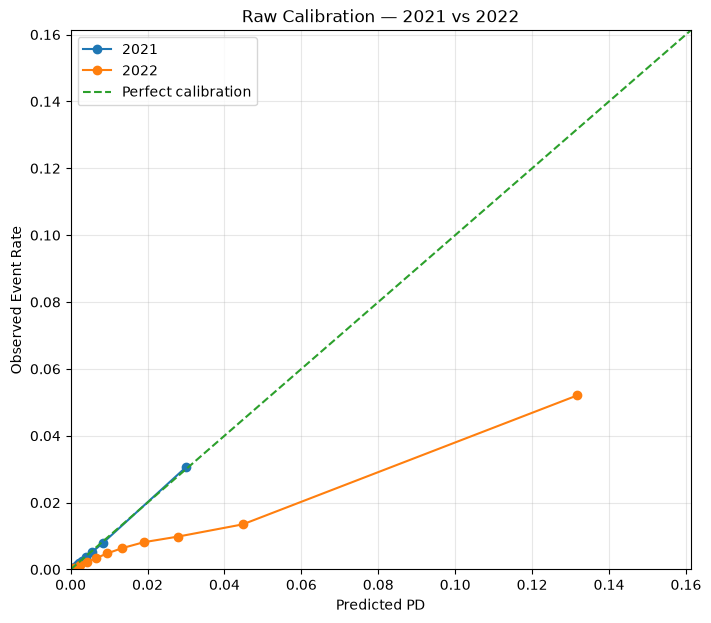

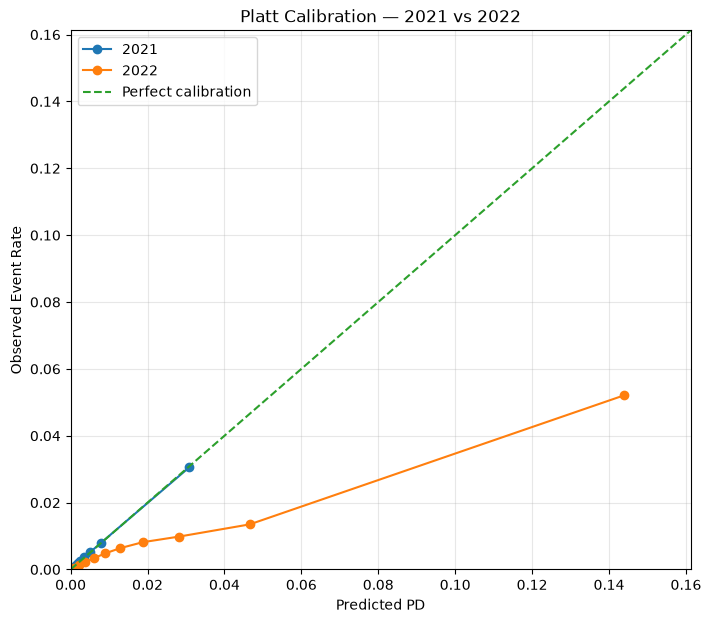

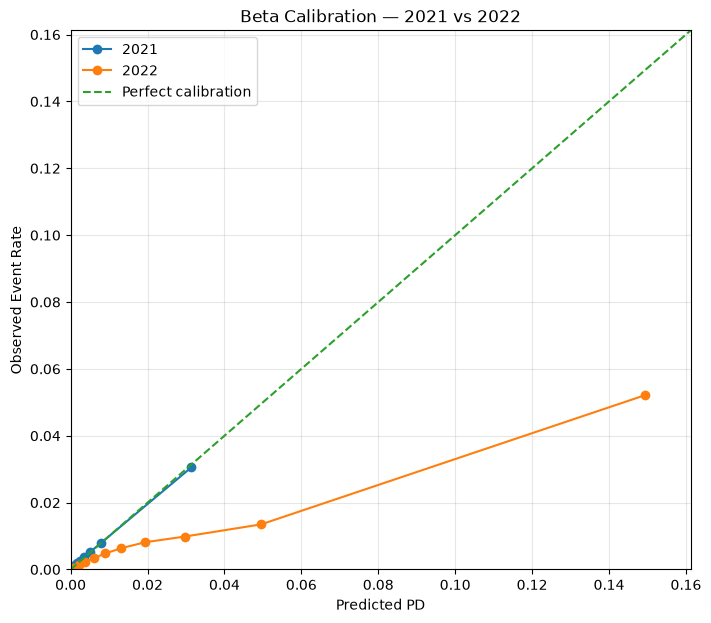

In [51]:
methods = ["Raw", "Platt", "Beta"]

upper = curve_df[
    curve_df["method"].isin(methods)
][["predicted", "observed"]].to_numpy().max() * 1.08

for method in methods:
    fig, ax = plt.subplots(figsize=(8, 7))

    for split in ["2021", "2022"]:
        d = curve_df[
            (curve_df["method"] == method)
            & (curve_df["split"] == split)
        ].sort_values("predicted")

        ax.plot(
            d["predicted"],
            d["observed"],
            marker="o",
            label=split,
        )

    ax.plot(
        [0, upper],
        [0, upper],
        linestyle="--",
        label="Perfect calibration",
    )

    ax.set_xlim(0, upper)
    ax.set_ylim(0, upper)
    ax.set_xlabel("Predicted PD")
    ax.set_ylabel("Observed Event Rate")
    ax.set_title(f"{method} Calibration — 2021 vs 2022")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()

# Part E — Temporal calibration stability

We now quantify the actual calibration relationship in each period.

For each vintage, fit:

\[
\operatorname{logit}(Y)=a+b\operatorname{logit}(p)
\]

**Important:** this section is diagnostic. The 2022 slope/intercept are estimated only to *measure* how the relationship changed; they are not used to calibrate the model.


In [52]:
def empirical_calibration_slope_intercept(scored):
    x = (
        scored
        .withColumn(
            "__p_clip",
            F.when(F.col("raw_pd") < EPS, EPS)
             .when(F.col("raw_pd") > 1 - EPS, 1 - EPS)
             .otherwise(F.col("raw_pd"))
        )
        .withColumn(
            "__logit",
            F.log(
                F.col("__p_clip") /
                (1 - F.col("__p_clip"))
            )
        )
        .withColumn(
            "__features",
            array_to_vector(F.array(F.col("__logit")))
        )
    )

    lr = LogisticRegression(
        featuresCol="__features",
        labelCol="label",
        fitIntercept=True,
        regParam=0.0,
        elasticNetParam=0.0,
        maxIter=100,
    )

    fitted = lr.fit(x.select("label", "__features"))

    return {
        "intercept": float(fitted.intercept),
        "slope": float(fitted.coefficients[0]),
    }


calibration_relationship = pd.DataFrame([
    {
        "split": "2021",
        **empirical_calibration_slope_intercept(val_scored),
    },
    {
        "split": "2022",
        **empirical_calibration_slope_intercept(oot_scored),
    },
])

display(calibration_relationship)

26/09/05 17:23:18 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:23:21 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:23:21 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:23:21 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:23:24 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:23:24 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:23:24 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:23:24 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:23:24 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:23:25 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:23:25 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/09/05 17:23:25 WARN DAGScheduler: Broadcasting larg

,split,intercept,slope
0,2021,0.237054,1.064066
1,2022,-1.255419,0.934104


### Interpretation of the slope

If 2021 has slope ≈ 1 but 2022 has a substantially smaller slope:

> The model becomes **overconfident / too extreme** in 2022.

If the slope stays near 1 but the intercept shifts:

> The dominant issue is a **PD-level/base-rate shift**.

If both change substantially:

> Both probability level and extremeness changed.


# Part F — 2021 → 2022 population / feature drift

A calibration change can happen because the feature population moved into a different region.

We therefore compare the actual model-input features in 2021 and 2022.

The feature list is taken from the persisted training configuration, so this does not accidentally analyze unrelated columns.


In [53]:

features_config = scoring_config["parameters"]["modelling"]["features"]

numerical_features = list(
    features_config.get("numerical_features", [])
)

categorical_features = list(
    features_config.get("categorical_features", [])
)

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))


Numerical features: 49
Categorical features: 12


## Numerical drift

PSI is used as a screening statistic. It is **not** treated as proof of model instability.

Bins are defined from the 2021 distribution and then applied unchanged to 2022.


In [56]:
import numpy as np
def calculate_psi_from_counts(expected, actual, eps=1e-6):
    expected = np.asarray(expected, dtype=float) + eps
    actual = np.asarray(actual, dtype=float) + eps

    expected /= expected.sum()
    actual /= actual.sum()

    return float(
        np.sum(
            (actual - expected)
            * np.log(actual / expected)
        )
    )

def numerical_feature_psi(feature, n_bins=10):
    if feature not in validation_df.columns or feature not in oot_df.columns:
        return None

    v = (
        validation_df
        .select(F.col(feature).cast("double").alias("x"))
        .filter(F.col("x").isNotNull())
    )

    o = (
        oot_df
        .select(F.col(feature).cast("double").alias("x"))
        .filter(F.col("x").isNotNull())
    )

    quantiles = v.approxQuantile(
        "x",
        [i / n_bins for i in range(n_bins + 1)],
        0.001,
    )

    quantiles = sorted(
        set(float(q) for q in quantiles if np.isfinite(q))
    )

    if len(quantiles) < 3:
        return {
            "feature": feature,
            "PSI": np.nan,
            "mean_2021": v.agg(F.avg("x")).first()[0],
            "mean_2022": o.agg(F.avg("x")).first()[0],
        }

    boundaries = [-np.inf] + quantiles[1:-1] + [np.inf]

    def bucket_expr():
        expr = F.lit(len(boundaries) - 2)

        for i in range(len(boundaries) - 2, -1, -1):
            expr = F.when(
                F.col("x") < F.lit(boundaries[i + 1]),
                F.lit(i),
            ).otherwise(expr)

        return expr

    def counts(df):
        return (
            df.withColumn("bin", bucket_expr())
              .groupBy("bin")
              .count()
              .toPandas()
        )

    c21 = counts(v).set_index("bin")["count"]
    c22 = counts(o).set_index("bin")["count"]

    expected = [
        c21.get(i, 0)
        for i in range(len(boundaries) - 1)
    ]

    actual = [
        c22.get(i, 0)
        for i in range(len(boundaries) - 1)
    ]

    return {
        "feature": feature,
        "PSI": calculate_psi_from_counts(expected, actual),
        "mean_2021": v.agg(F.avg("x")).first()[0],
        "mean_2022": o.agg(F.avg("x")).first()[0],
    }

numerical_drift_rows = []

for feature in numerical_features:
    try:
        result = numerical_feature_psi(feature)
        if result is not None:
            numerical_drift_rows.append(result)
    except Exception as exc:
        print(f"Failed for {feature}: {exc}")

numerical_drift_df = (
    pd.DataFrame(numerical_drift_rows)
    .sort_values("PSI", ascending=False)
    .reset_index(drop=True)
)

display(numerical_drift_df)


/home/vorad/mortgage-credit-risk/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/vorad/mortgage-credit-risk/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/vorad/mortgage-credit-risk/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/vorad/mortgage-credit-risk/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWar

,feature,PSI,mean_2021,mean_2022
0,current_interest_rate,2.936170,2.956035e+00,4.727254e+00
1,estimated_ltv,0.311647,6.089222e+01,7.054499e+01
2,upb_pct_change_from_origination,0.293467,-2.486257e-02,-2.211310e-02
3,original_ltv,0.096843,6.922694e+01,7.323768e+01
4,original_cltv,0.096087,6.941303e+01,7.336358e+01
5,remaining_months_to_legal_maturity,0.080943,3.113777e+02,3.294836e+02
6,original_dti,0.080527,3.395090e+01,3.664246e+01
7,mi_percentage,0.063334,4.962792e+00,7.868186e+00
8,months_since_last_60dpd,0.039500,2.663693e+00,2.109377e+00
9,credit_score,0.029195,7.512798e+02,7.437725e+02


## Categorical composition drift

For categoricals we compare the full level distribution between 2021 and 2022 and calculate PSI over the category proportions.


In [57]:

def categorical_feature_psi(feature):
    if feature not in validation_df.columns or feature not in oot_df.columns:
        return None

    def get_counts(df):
        return (
            df.select(
                F.coalesce(
                    F.col(feature).cast("string"),
                    F.lit("__NULL__"),
                ).alias("level")
            )
            .groupBy("level")
            .count()
            .toPandas()
        )

    c21 = get_counts(validation_df).set_index("level")["count"]
    c22 = get_counts(oot_df).set_index("level")["count"]

    levels = sorted(set(c21.index) | set(c22.index))

    expected = [c21.get(level, 0) for level in levels]
    actual = [c22.get(level, 0) for level in levels]

    return {
        "feature": feature,
        "PSI": calculate_psi_from_counts(expected, actual),
        "levels_2021": int(len(c21)),
        "levels_2022": int(len(c22)),
    }

categorical_drift_rows = []

for feature in categorical_features:
    try:
        result = categorical_feature_psi(feature)
        if result is not None:
            categorical_drift_rows.append(result)
    except Exception as exc:
        print(f"Failed for {feature}: {exc}")

categorical_drift_df = (
    pd.DataFrame(categorical_drift_rows)
    .sort_values("PSI", ascending=False)
    .reset_index(drop=True)
)

display(categorical_drift_df)


/home/vorad/mortgage-credit-risk/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/vorad/mortgage-credit-risk/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/vorad/mortgage-credit-risk/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/vorad/mortgage-credit-risk/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWar

,feature,PSI,levels_2021,levels_2022
0,loan_purpose,0.524260,3,3
1,property_state,0.047892,54,54
2,super_conforming_flag,0.020473,2,2
3,occupancy_status,0.018641,3,3
4,property_type,0.005237,5,5
5,channel,0.004658,3,3
6,borrower_assistance_plan,0.000139,4,4
7,delinquency_due_to_disaster,0.000014,2,2
8,modification_flag,0.000005,3,3
9,interest_rate_step_indicator,0.000005,2,2


# Part G — 2021 → 2022 target / prediction distribution shift

This checks whether the actual target rate and the model's prediction distribution moved together.


In [59]:
def prediction_distribution_summary(scored, split):
    return (
        scored.select("raw_pd")
        .agg(
            F.avg("raw_pd").alias("mean_pd"),
            F.expr("percentile_approx(raw_pd, 0.01)").alias("p01"),
            F.expr("percentile_approx(raw_pd, 0.05)").alias("p05"),
            F.expr("percentile_approx(raw_pd, 0.25)").alias("p25"),
            F.expr("percentile_approx(raw_pd, 0.50)").alias("p50"),
            F.expr("percentile_approx(raw_pd, 0.75)").alias("p75"),
            F.expr("percentile_approx(raw_pd, 0.95)").alias("p95"),
            F.expr("percentile_approx(raw_pd, 0.99)").alias("p99"),
            F.max("raw_pd").alias("max_pd"),
        )
        .toPandas()
        .assign(split=split)
    )

prediction_distribution = pd.concat([
    prediction_distribution_summary(val_scored, "2021"),
    prediction_distribution_summary(oot_scored, "2022"),
], ignore_index=True)

display(prediction_distribution)

/home/vorad/mortgage-credit-risk/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/05 17:27:57 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
/home/vorad/mortgage-credit-risk/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/05 17:28:03 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
                                                                                

,mean_pd,p01,p05,p25,p50,p75,p95,p99,max_pd,split
0,0.005640,0.000130,0.000343,0.001087,0.002469,0.005469,0.015795,0.036918,1.0,2021
1,0.026074,0.000342,0.001004,0.004285,0.011217,0.027658,0.090121,0.218455,1.0,2022


# Part H — Final automatic diagnosis

This does not replace judgement, but it summarizes the evidence we have collected.


In [63]:
core_df_pd = core_df.toPandas()

m21 = core_df_pd.loc[core_df_pd["split"] == "2021"].iloc[0]
m22 = core_df_pd.loc[core_df_pd["split"] == "2022"].iloc[0]

auc_change = m22["ROC_AUC"] - m21["ROC_AUC"]
ks_change = m22["KS"] - m21["KS"]

print("=" * 80)
print("V3 TEMPORAL CALIBRATION DIAGNOSTIC")
print("=" * 80)

print(f"2021 event rate       : {m21['event_rate']:.6%}")
print(f"2022 event rate       : {m22['event_rate']:.6%}")
print(f"2021 mean PD          : {m21['mean_predicted_pd']:.6%}")
print(f"2022 mean PD          : {m22['mean_predicted_pd']:.6%}")
print(f"2021 O/E              : {m21['O/E']:.4f}")
print(f"2022 O/E              : {m22['O/E']:.4f}")
print(f"2021 ROC-AUC          : {m21['ROC_AUC']:.4f}")
print(f"2022 ROC-AUC          : {m22['ROC_AUC']:.4f}")
print(f"2021 KS               : {m21['KS']:.4f}")
print(f"2022 KS               : {m22['KS']:.4f}")
print(f"AUC change            : {auc_change:+.4f}")
print(f"KS change             : {ks_change:+.4f}")
print()

print("Calibration relationship:")
display(calibration_relationship)

print()
print("Platt calibration fitted ONLY on 2021:")
print(f"  intercept a = {platt_a:.6f}")
print(f"  slope b     = {platt_b:.6f}")

if abs(auc_change) < 0.02 and abs(ks_change) < 0.03 and m22["O/E"] < 0.70:
    print("\nPRIMARY DIAGNOSIS:")
    print("→ Discrimination remains relatively stable.")
    print("→ The PD scale deteriorates materially in 2022.")
    print("→ The dominant calibration change is a large probability-level shift.")
    print("→ Feature/population drift is a plausible driver of this temporal instability.")
    print("→ Treat this as TEMPORAL CALIBRATION + REGIME/POPULATION SHIFT.")

elif abs(auc_change) >= 0.02 or abs(ks_change) >= 0.03:
    print("\nPRIMARY DIAGNOSIS:")
    print("→ Discrimination also changes materially.")
    print("→ Investigate broader MODEL / POPULATION DRIFT before treating this as calibration-only.")

else:
    print("\nPRIMARY DIAGNOSIS:")
    print("→ No single diagnosis is decisive.")
    print("→ Inspect calibration curves, decile gaps, calibration slope,")
    print("  score distribution, and feature PSI together.")

print("\nIMPORTANT:")
print("2022 was NOT used to fit any calibration model.")

/home/vorad/mortgage-credit-risk/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


V3 TEMPORAL CALIBRATION DIAGNOSTIC
2021 event rate       : 0.544778%
2022 event rate       : 1.024242%
2021 mean PD          : 0.564035%
2022 mean PD          : 2.607401%
2021 O/E              : 0.9659
2022 O/E              : 0.3928
2021 ROC-AUC          : 0.8422
2022 ROC-AUC          : 0.8123
2021 KS               : 0.5106
2022 KS               : 0.4465
AUC change            : -0.0299
KS change             : -0.0641

Calibration relationship:


,split,intercept,slope
0,2021,0.237054,1.064066
1,2022,-1.255419,0.934104



Platt calibration fitted ONLY on 2021:
  intercept a = 0.237054
  slope b     = 1.064066

PRIMARY DIAGNOSIS:
→ Discrimination also changes materially.
→ Investigate broader MODEL / POPULATION DRIFT before treating this as calibration-only.

IMPORTANT:
2022 was NOT used to fit any calibration model.


# Part I — What we should conclude from the notebook

Use the following decision framework:

### 1. 2021 good + 2022 bad calibration, but AUC/KS stable
This supports:

> **The V3 model retains ranking power but its probability mapping is unstable in 2022.**

Next step: investigate a temporally robust calibration strategy.

### 2. Platt slope substantially below 1
This supports:

> **The raw GAM probabilities are too extreme in 2022.**

Compare whether Platt materially improves 2022 O/E, Brier and LogLoss without sacrificing useful ranking.

### 3. Intercept-only works almost as well as Platt
Then the main issue is likely a **level/base-rate shift**, not overconfidence.

### 4. Platt materially beats intercept-only
Then there is an additional **calibration-slope / extremeness problem**.

### 5. AUC / KS also deteriorate
Do not treat calibration as the entire problem. Investigate population/concept drift and feature-level stability.

### 6. Beta improves 2021 but worsens 2022
That is evidence that the previous beta calibration is **not temporally transferable**. Do not select it merely because it improves the validation curve.

**Most importantly:** do not tune anything against 2022 after seeing these results. Use 2021 to select the approach, freeze it, and use 2022 as the final OOT test.


In [7]:
from pyspark.sql import functions as F

train_df = spark.read.parquet(
    "data/04_model_split/behavioral/train_split.parquet"
)

validation_df = spark.read.parquet(
    "data/04_model_split/behavioral/validation_split.parquet"
)

oot_df = spark.read.parquet(
    "data/04_model_split/behavioral/oot_split.parquet"
)

train_ids = train_df.select("loan_id").distinct()
validation_ids = validation_df.select("loan_id").distinct()
oot_ids = oot_df.select("loan_id").distinct()

print("Distinct loan IDs:")
print("Train:      ", train_ids.count())
print("Validation: ", validation_ids.count())
print("OOT:        ", oot_ids.count())

train_validation = train_ids.join(
    validation_ids,
    on="loan_id",
    how="inner",
)

train_oot = train_ids.join(
    oot_ids,
    on="loan_id",
    how="inner",
)

validation_oot = validation_ids.join(
    oot_ids,
    on="loan_id",
    how="inner",
)

print("\nCross-split loan ID overlap:")
print("Train ∩ Validation:", train_validation.count())
print("Train ∩ OOT:       ", train_oot.count())
print("Validation ∩ OOT:  ", validation_oot.count())

Distinct loan IDs:


Train:       11351574


Validation:  4058328
OOT:         1561946

Cross-split loan ID overlap:


Train ∩ Validation: 0


Train ∩ OOT:        0


[Stage 299:============>(182 + 5) / 187][Stage 300:===========>  (68 + 12) / 80]

Validation ∩ OOT:   0
